In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *
from ADFWI.fwi         import *
from ADFWI.dip         import *
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

project_path = "./examples/dip/DIP-ADFWI/01_Multi-CNN/data"
layer_num = 2
if not os.path.exists(os.path.join(project_path,"model")):
    os.makedirs(os.path.join(project_path,"model"))
if not os.path.exists(os.path.join(project_path,"waveform")):
    os.makedirs(os.path.join(project_path,"waveform"))
if not os.path.exists(os.path.join(project_path,"survey")):
    os.makedirs(os.path.join(project_path,"survey"))
if not os.path.exists(os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test")):
    os.makedirs(os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test"))

In [2]:
#------------------------------------------------------
#                   Basic Parameters
#------------------------------------------------------
device = "cuda:0"
dtype  = torch.float32
ox,oz  = 0,0
nz,nx  = 88,200
dx,dz  = 40, 40
nt,dt  = 1600, 0.003
nabc   = 30
f0     = 5
free_surface = True

In [ ]:
#------------------------------------------------------
#                   Velocity Model
#------------------------------------------------------
# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="/ailab/user/liufeng1/project/04_Inversion/ADFWI-github/examples/datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(5000, 5000 + dx * nx, nx)
z = np.linspace(0, dz * nz, nz)
true_model   = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6)

# Initialize primary wave velocity (vp) and density (rho) for the model.
vp_init = smooth_model['vp'].T  # Transpose to match dimensions
rho_init = np.power(vp_init, 0.25) * 310  # Calculate density based on vp

# Extract true model properties for comparison.
vp_true = true_model['vp'].T  # Transpose for consistency
rho_true = np.power(vp_true, 0.25) * 310  # Calculate true density

In [4]:
# -----------------------------------
#     Define DIP model
# -----------------------------------
model_shape = [nz,nx]
DIP_model = DIP_CNN(model_shape,in_channels=[4,32],vmin=vp_true.min()/1000,vmax=vp_true.max()/1000,device=device)
DIP_model.to(device)

CNN(
  (FNN_in): Sequential(
    (0): Linear(in_features=100, out_features=17600, bias=False)
    (1): Unflatten(dim=0, unflattened_size=(-1, 4, 44, 100))
    (2): LeakyReLU(negative_slope=0.1)
  )
  (CNN_Blocks): ModuleList(
    (0): Sequential(
      (0): UpsamplingBilinear2d(scale_factor=(2.0, 2.0), mode='bilinear')
      (1): Conv2d(4, 32, kernel_size=(4, 4), stride=(1, 1), padding=same, bias=False)
      (2): LeakyReLU(negative_slope=0.1)
      (3): Dropout(p=0, inplace=False)
    )
  )
  (CNN_out): Sequential(
    (0): Conv2d(32, 1, kernel_size=(4, 4), stride=(1, 1), padding=same, bias=False)
  )
)

In [ ]:
# -----------------------------------
#     Pretrain DIP model
# -----------------------------------
pretrain        = True
load_pretrained = True
if pretrain:
    if load_pretrained:
        # load the model parameters
        DIP_model.load_state_dict(torch.load(os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test/DIP_model_pretrained.pt")))
    else:
        lr          = 0.005
        iteration   = 10000
        step_size   = 1000
        gamma       = 0.5
        optimizer = torch.optim.Adam(DIP_model.parameters(),lr = lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=step_size,gamma=gamma)
        vp_init = numpy2tensor(vp_init,dtype=dtype).to(device)
        pbar = tqdm(range(iteration+1))
        for i in pbar:  
            vp_nn = DIP_model()
            loss = torch.sqrt(torch.sum((vp_nn - vp_init)**2))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            pbar.set_description(f'Pretrain Iter:{i}, Misfit:{loss.cpu().detach().numpy()}')
        torch.save(DIP_model.state_dict(),os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test/DIP_model_pretrained.pt"))


In [6]:
# -----------------------------------
#     velocity model for FWI
# -----------------------------------
water_layer_mask = np.zeros((vp_init.shape[0],vp_init.shape[1]))
water_layer_mask[:10,:] = 1
model = DIP_AcousticModel(ox,oz,nx,nz,dx,dz,
                        DIP_model_vp=DIP_model,
                        DIP_model_rho=None,
                        vp_init=vp_init,rho_init=rho_init,
                        auto_update_rho=True,auto_update_vp=False,
                        water_layer_mask=water_layer_mask,
                        free_surface=free_surface,
                        abc_type="PML",abc_jerjan_alpha=0.007,
                        nabc=nabc,
                        device=device,dtype=dtype)
print(model.__repr__())
model.save(os.path.join(project_path,"model/init_model.npz"))

   Model with parameters ['vp', 'rho']:
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  40.00, dz =  40.00 m
  Model dims: nx =    200, nz =     88
  Model size: 35200
  Free surface: True
  Absorbing layers: 30
  NN structure
Layer (type:depth-idx)                        Param #
CNN                                           --
├─Sequential: 1-1                             --
│    └─Linear: 2-1                            1,760,000
│    └─Unflatten: 2-2                         --
│    └─LeakyReLU: 2-3                         --
├─ModuleList: 1-2                             --
│    └─Sequential: 2-4                        --
│    │    └─UpsamplingBilinear2d: 3-1         --
│    │    └─Conv2d: 3-2                       2,048
│    │    └─LeakyReLU: 3-3                    --
│    │    └─Dropout: 3-4                      --
├─Sequential: 1-3                             --
│    └─Conv2d: 2-5                            512
Total params: 1,762,560
Trainable params: 1,762,560
Non-tr

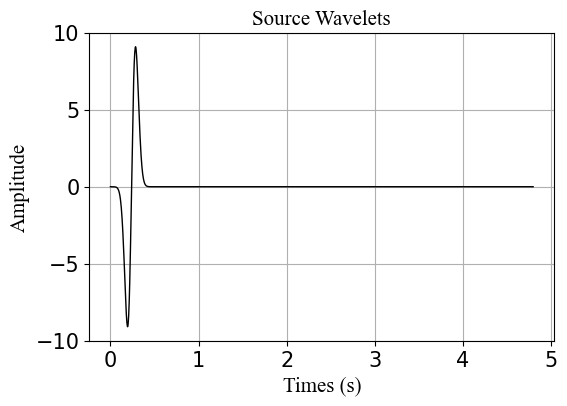

Survey Information:
Seismic Source:
  Source wavelet: 1600 samples at 3.00 ms
  Source number : 40
  Source types  : ['mt']
  Source x range: 2 - 197 (grids)
  Source z range: 1 - 1 (grids)

Seismic Receiver:
  Receiver data   : 1600 samples at 3.00 ms
  Receiver number : 200
  Receiver types  : ['pr']
  Receiver x range: 0 - 199 (grids)
  Receiver z range: 1 - 1 (grids)



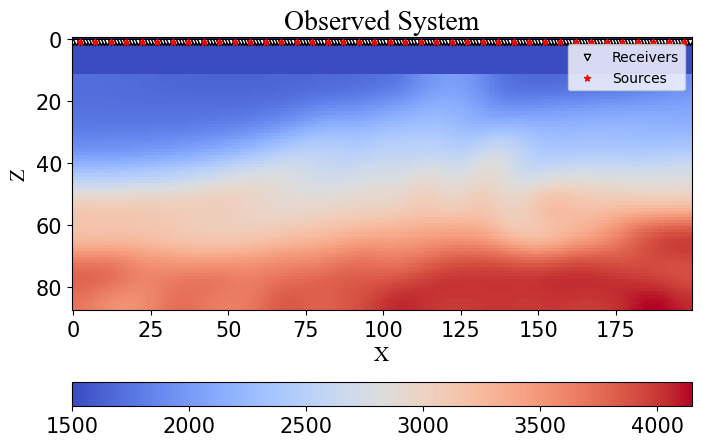

In [7]:
#------------------------------------------------------
#                   Source And Receiver
#------------------------------------------------------
# source    
src_z = np.array([1 for i in range(2, nx-1, 5)])  # Z-coordinates for sources
src_x = np.array([i for i in range(2, nx-1, 5)])  # X-coordinates for sources
src_t,src_v = wavelet(nt,dt,f0,amp0=1)
src_v = integrate.cumtrapz(src_v, axis=-1, initial=0) #Integrate
source = Source(nt=nt,dt=dt,f0=f0)
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i],src_z=src_z[i],src_wavelet=src_v,src_type="mt",src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))
source.plot_wavelet(save_path=os.path.join(project_path,"survey/wavelets.png"),show=True)

# receiver
rcv_z = np.array([1 for i in range(0, nx, 1)])  # Z-coordinates for receivers
rcv_x = np.array([j for j in range(0, nx, 1)])  # X-coordinates for receivers
receiver = Receiver(nt=nt,dt=dt)
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i],rcv_z=rcv_z[i],rcv_type="pr")

# survey
survey = Survey(source=source,receiver=receiver)
print(survey.__repr__())
survey.plot(model.vp,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"),show=True)


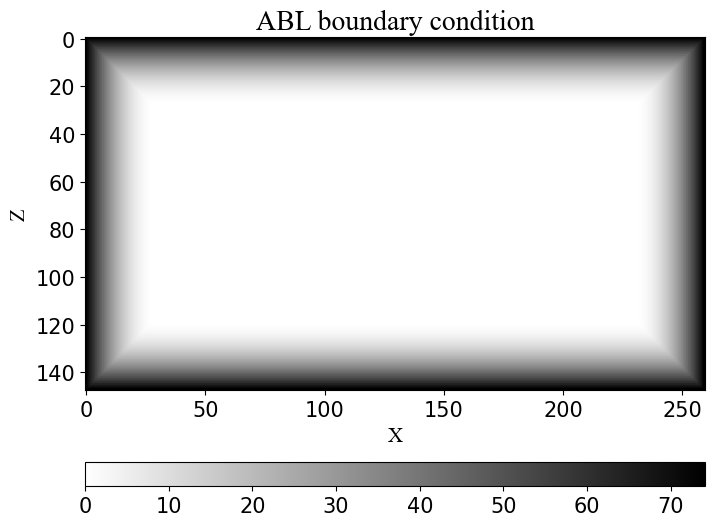

Seismic Data:
  Source number : 40
  Receiver number : 200
  Time samples : 1600 samples at 3.00 ms



In [8]:
#------------------------------------------------------
#                   Waveform Propagator
#------------------------------------------------------
F = AcousticPropagator(model,survey,device=device)
damp = F.damp
plot_damp(damp,save_path=os.path.join(project_path,"model/boundary_condition_init.png"),show=True)

# load data
d_obs = SeismicData(survey)
d_obs.load(os.path.join(project_path,"waveform/obs_data.npz"))
print(d_obs.__repr__())

In [ ]:
# optimizer
iteration   =   100
optimizer   =   torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler   =   torch.optim.lr_scheduler.StepLR(optimizer,step_size=100,gamma=0.75,last_epoch=-1)

# Setup misfit function
from ADFWI.fwi.misfit import Misfit_global_correlation
loss_fn = Misfit_global_correlation(dt=1)

# gradient processor
grad_mask = np.ones((vp_init.shape[0],vp_init.shape[1]))
grad_mask[:10,:] = 0
gradient_processor = GradProcessor(grad_mask=grad_mask)

 # gradient processor
fwi = DIP_AcousticFWI(propagator=F,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    loss_fn=loss_fn,
                    obs_data=d_obs,
                    gradient_processor=gradient_processor,
                    waveform_normalize=True,
                    cache_result=True,
                    save_fig_epoch=50,
                    save_fig_path=os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test")
                    )

fwi.forward(iteration=iteration,batch_size=None,checkpoint_segments=1)

iter_vp     = fwi.iter_vp
iter_loss   = fwi.iter_loss 
np.savez(os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test/iter_vp.npz"),data=np.array(iter_vp))
np.savez(os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test/iter_loss.npz"),data=np.array(iter_loss))
torch.save(model.DIP_model_vp.state_dict(),os.path.join(project_path,f"inversion-{layer_num}layer-4-32-test/DIP_model.pt"))


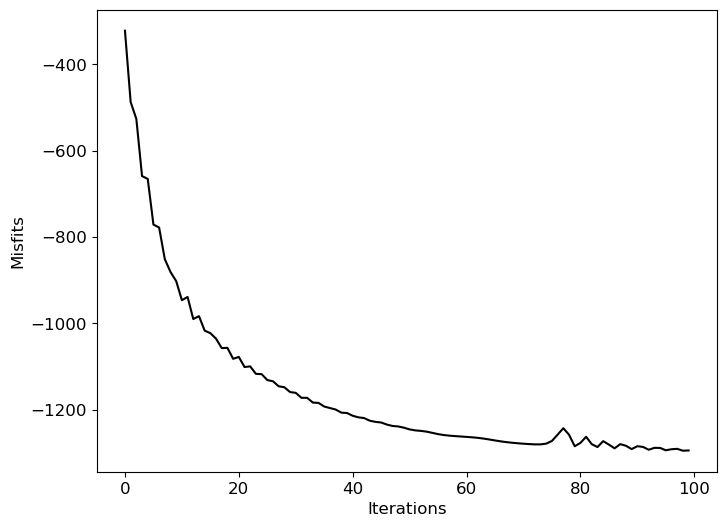

In [10]:
# plot the misfit
plt.figure(figsize=(8,6))
plt.plot(iter_loss,c='k')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Misfits", fontsize=12)
plt.tick_params(labelsize=12)
plt.show()

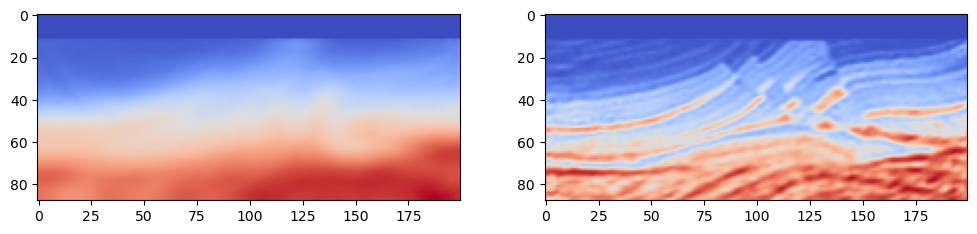

In [11]:
# plot the initial model and inverted resutls
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(iter_vp[0],cmap='coolwarm')
plt.subplot(122)
plt.imshow(iter_vp[-1],cmap='coolwarm')
plt.show()